In [1]:
from pyxpcsviewer import XpcsFile as XF
import matplotlib.pyplot as plt

In [2]:
!ls ../test_datasets

A0029_CPMV_a0007_f100000_r00001_results.hdf


In [3]:
# create a result file object, using the relative path to the file
xf_obj = XF("../test_datasets/A0029_CPMV_a0007_f100000_r00001_results.hdf")

In [4]:
# list all properties and functions defined in XpcsFile
# dir(xf_obj)

In [5]:
# t_el is the delay list in second
print(xf_obj.t_el)

[2.00000e-05 4.00000e-05 6.00000e-05 8.00000e-05 1.00000e-04 1.20000e-04
 1.40000e-04 1.60000e-04 2.00000e-04 2.40000e-04 2.80000e-04 3.20000e-04
 4.00000e-04 4.80000e-04 5.60000e-04 6.40000e-04 8.00000e-04 9.60000e-04
 1.12000e-03 1.28000e-03 1.60000e-03 1.92000e-03 2.24000e-03 2.56000e-03
 3.20000e-03 3.84000e-03 4.48000e-03 5.12000e-03 6.40000e-03 7.68000e-03
 8.96000e-03 1.02400e-02 1.28000e-02 1.53600e-02 1.79200e-02 2.04800e-02
 2.56000e-02 3.07200e-02 3.58400e-02 4.09600e-02 5.12000e-02 6.14400e-02
 7.16800e-02 8.19200e-02 1.02400e-01 1.22880e-01 1.43360e-01 1.63840e-01
 2.04800e-01 2.45760e-01 2.86720e-01 3.27680e-01 4.09600e-01 4.91520e-01
 5.73440e-01 6.55360e-01 8.19200e-01 9.83040e-01 1.14688e+00 1.31072e+00
 1.63840e+00]


In [6]:
# tau is the delay in frame
print(xf_obj.tau)

[    1     2     3     4     5     6     7     8    10    12    14    16
    20    24    28    32    40    48    56    64    80    96   112   128
   160   192   224   256   320   384   448   512   640   768   896  1024
  1280  1536  1792  2048  2560  3072  3584  4096  5120  6144  7168  8192
 10240 12288 14336 16384 20480 24576 28672 32768 40960 49152 57344 65536
 81920]


In [7]:
# the qmap used for the analysis. It is a complex object it self
# dir(xf_obj.qmap)

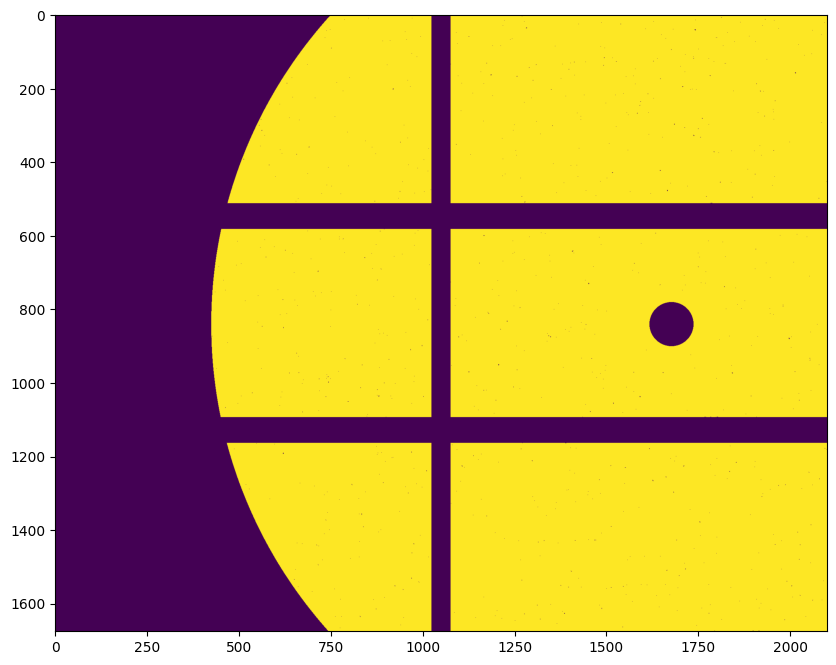

In [8]:
plt.imshow(xf_obj.qmap.mask)

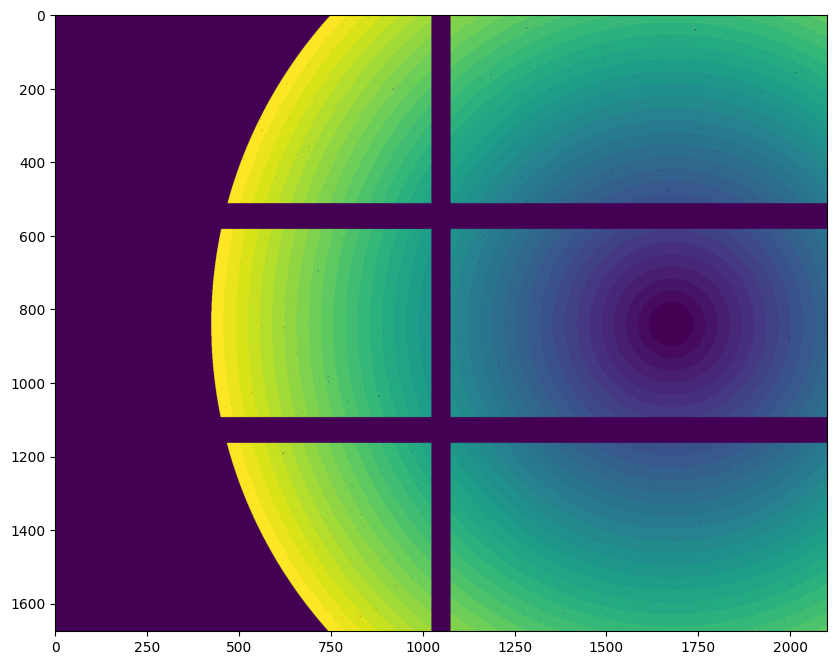

In [9]:
plt.imshow(xf_obj.qmap.dqmap)

In [10]:
# get g2 data from xf object. 
q, delays, g2, g2_err, labels = xf_obj.get_g2_data()
print(q.shape)
print(delays.shape)
print(g2.shape)

(36,)
(61,)
(61, 36)


Text(0.5, 1.0, 'q=0.00308 1/Å')

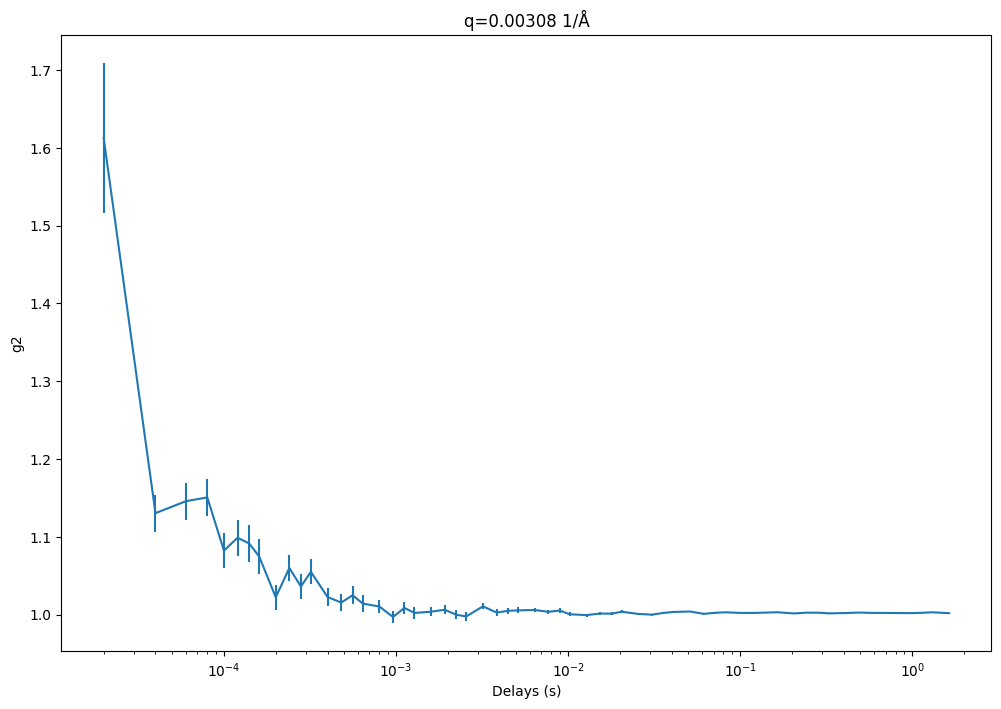

In [11]:
# plot the first qbin
plt.errorbar(delays, g2[:, 0], yerr=g2_err[:, 0])
plt.xlabel("Delays (s)")
plt.ylabel("g2")
plt.xscale("log")
plt.title(labels[0])

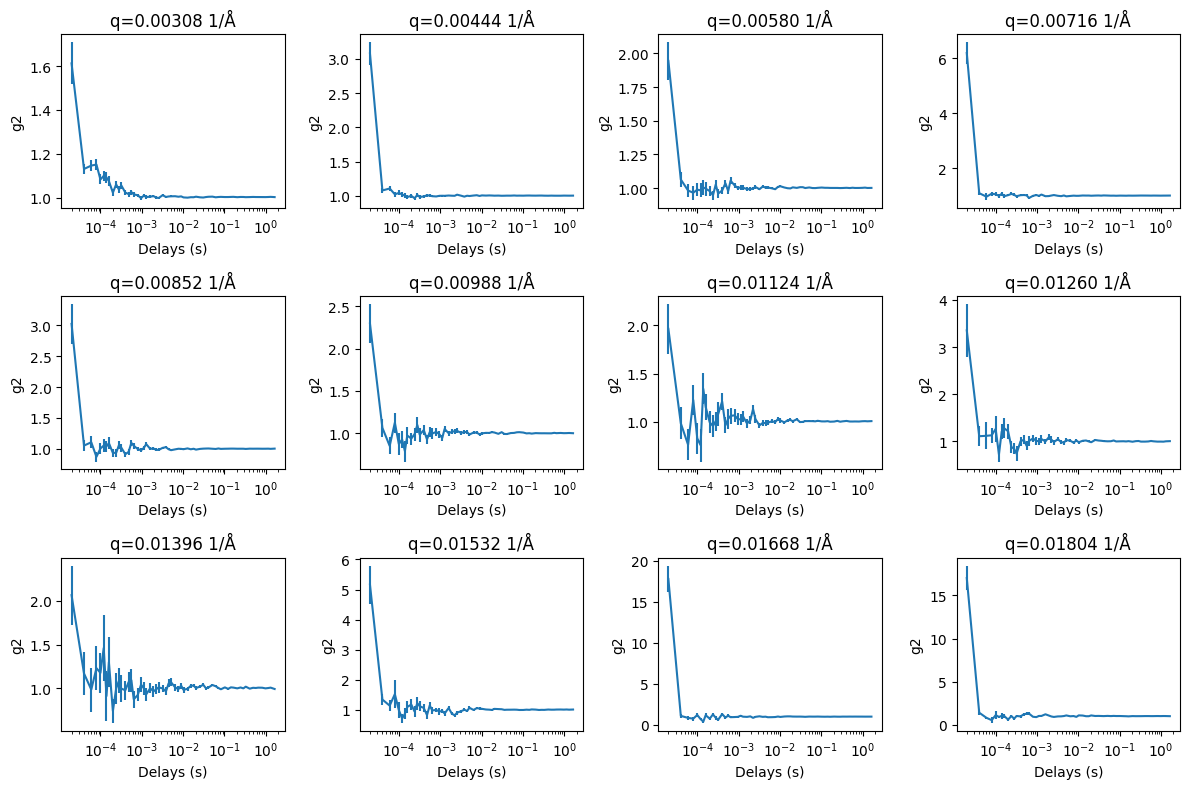

In [12]:
# plot the first 12 qbin
fig, ax = plt.subplots(3, 4)
ax = ax.flatten()
for n in range(len(ax)):
    ax[n].errorbar(delays, g2[:, n], yerr=g2_err[:, n])
    ax[n].set_xlabel("Delays (s)")
    ax[n].set_ylabel("g2")
    ax[n].set_xscale("log")
    ax[n].set_title(labels[n])
plt.tight_layout()

/tmp/ipykernel_2970295/3541616950.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(xf_obj.saxs_2d))


Text(0.5, 1.0, 'A0029_CPMV_a7_f100000_r1')

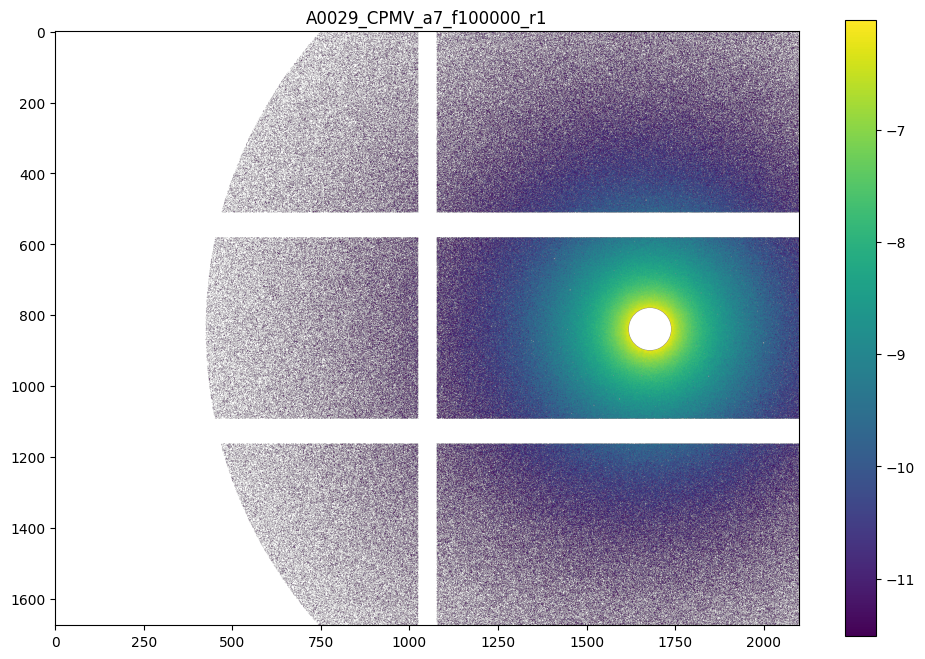

In [13]:
# plot saxs
plt.imshow(np.log(xf_obj.saxs_2d))
plt.colorbar()
plt.title(xf_obj.label)

Text(0.5, 1.0, 'A0029_CPMV_a7_f100000_r1')

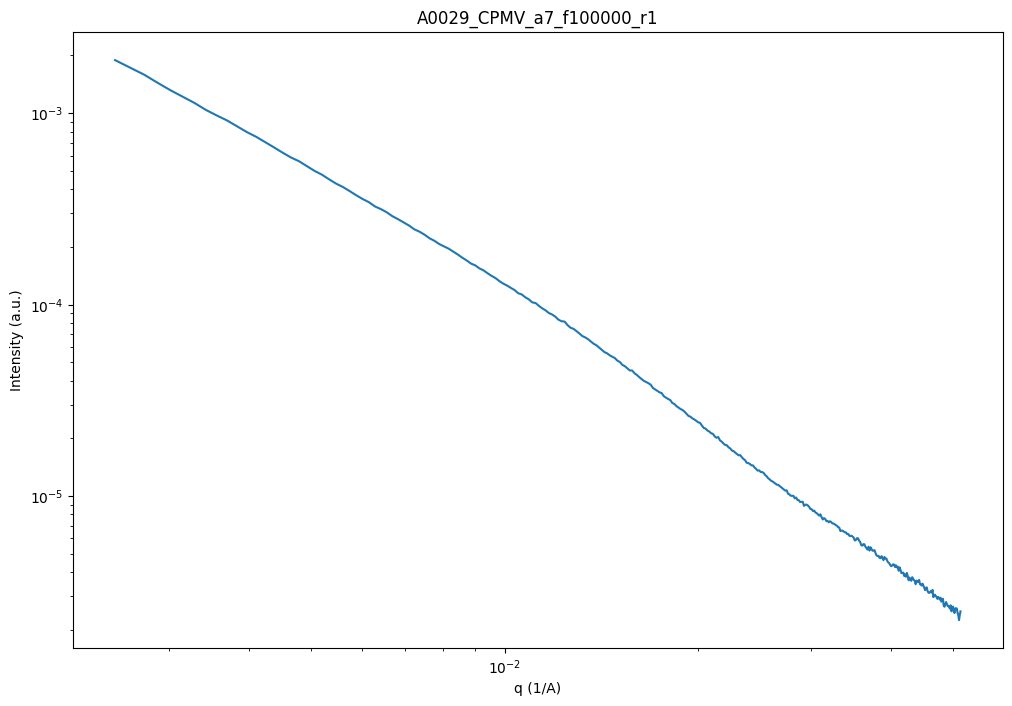

In [14]:
# plot saxs1d
# plot saxs
q, Iq = xf_obj.saxs_1d["q"], xf_obj.saxs_1d["Iq"][0]
plt.loglog(q, Iq)
plt.xlabel("q (1/A)")
plt.ylabel("Intensity (a.u.)")
plt.title(xf_obj.label)
# plt.colorbar()

Text(0.5, 1.0, 'A0029_CPMV_a7_f100000_r1')

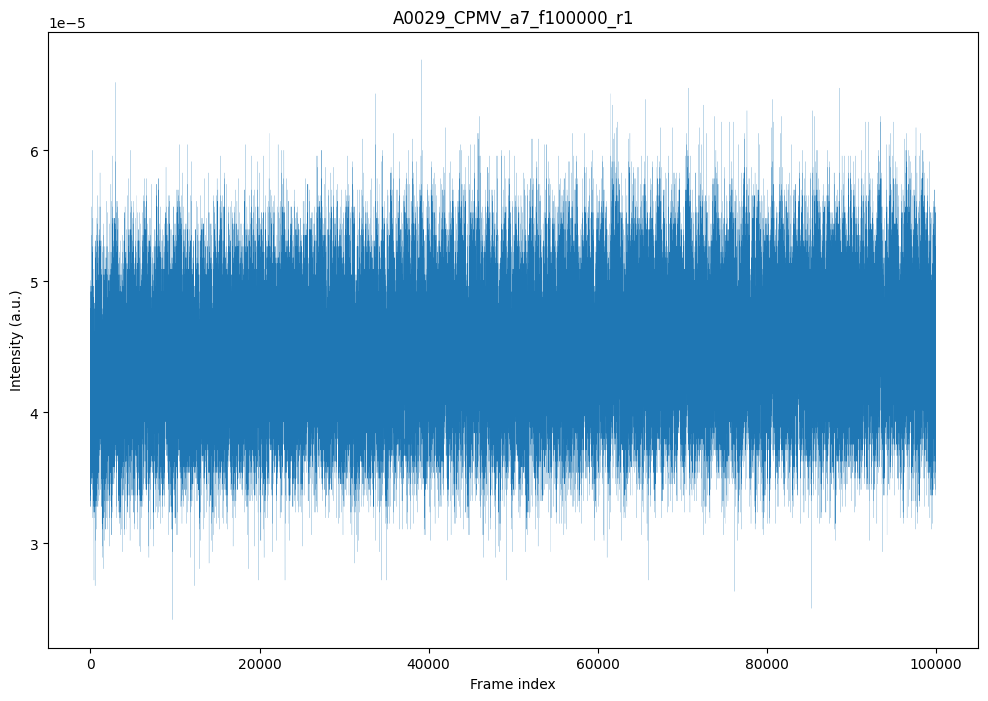

In [15]:
# plot intensity vs time
plt.plot(xf_obj.Int_t[0], xf_obj.Int_t[1], linewidth=0.1)
plt.xlabel("Frame index")
plt.ylabel("Intensity (a.u.)")
plt.title(xf_obj.label)